# DESI QSO Simulations

In [1]:
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table, vstack, MaskedColumn
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *
from Simulation.fitMap import *
from Simulation.lumMag_sampling import *
from Simulation.mappers import DensityMapper, FracCovMapper

In [2]:
nside = 128
npix= hp.nside2npix(nside)
area_deg2 = hp.nside2pixarea(nside, degrees=True)
print("Number of pixels = {}".format(npix))
print("Surface of a pixel = {} deg^2".format(area_deg2))

Number of pixels = 196608
Surface of a pixel = 0.2098234113027917 deg^2


## FRACCOV

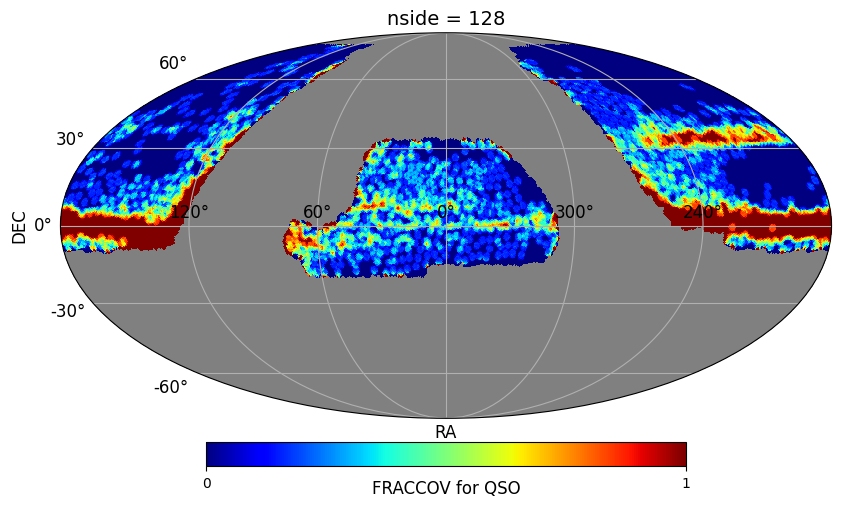

In [3]:
#File name:
DIR = "data/Data DESI/"
FILE_DR1 = DIR + "dr1-main-dark.fits"

sources="QSO"

outputDIR = DIR + f"DESI Figures/DESI DR1 {sources}/" #to save figures
output_path_data = outputDIR + f"DESI_DR1_{sources}_Data/" #common suffix to every figures
output_path_Simu = outputDIR + f"DESI_DR1_{sources}_Simul/"
suffix_data = f"DESI_DR1_{sources}_Density_map_"
suffix_Simu = f"DESI_DR1_{sources}_Simul_Density_map_"

#Reading file:
DR1_Mapper = FracCovMapper.read(FILE_DR1, nest=True)
DR1_Mapper.get_nside(nside)
DR1_Mapper._set_suffixTextPlot(unit = sources) #to customize the unit of plots.
DR1_Mapper.plot(use_map = "nside", title = f"nside = {DR1_Mapper.nside}")

## Density

### From DESI data

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.492e+06 (χ²/ndof = 12.7) │              Nfcn = 359              │
│ EDM = 1.23e-05 (Goal: 0.0002)    │           time = 11.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   79.93   │   0.05    │   -0.05    │    0.05    │    0    │         │       │
│ 1 │ A    │  0.6125   │  0.0013   │  -0.0013   │   0.0013   │    0    │    1    │       │
│ 2 │ ra   │  186.22   │   0.24    │   -0.24    │    0.24    │    0    │   360   │       │
│ 3 │ dec  │  -70.06   │   0.06    │   -0.06    │    0.06    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.05    │  -0.0013  │  0.0013   │   -0.24   │   0.24    │   -0.06   │   0.06    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0027  34.1e-6   0.0005  -0.0009 │
│   A │  34.1e-6 1.62e-06  38.9e-6 -18.4e-6 │
│  ra │   0.0005  38.9e-6   0.0571   -0.000 │
│ dec │  -0.0009 -18.4e-6   -0.000   0.0039 │
└─────┴─────────────────────────────────────┘

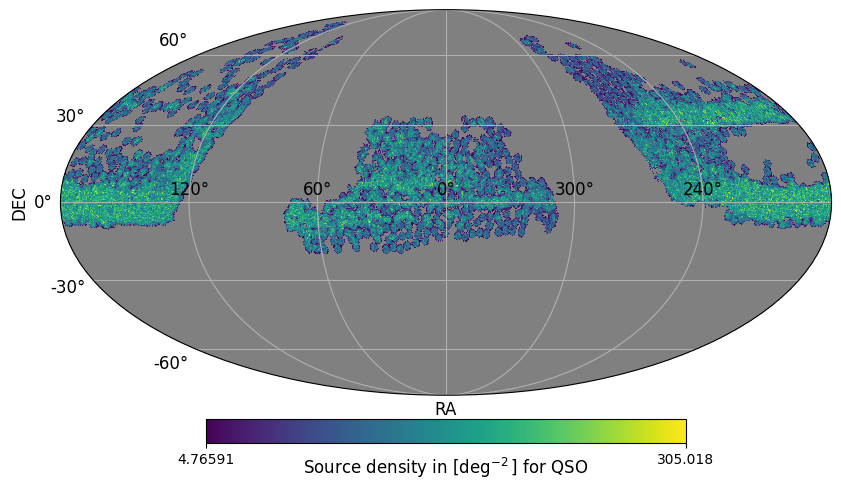

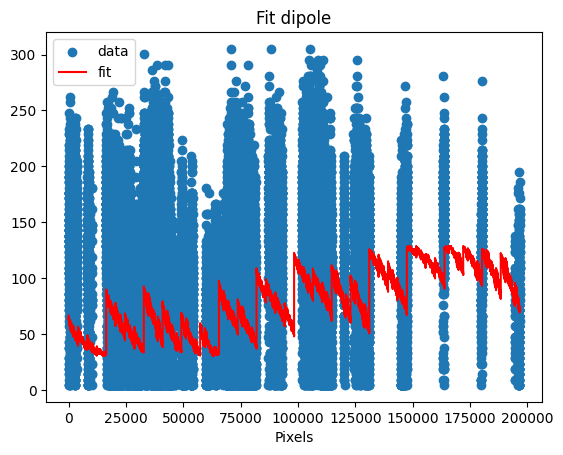

In [4]:
#File names:
FILE_NGC = DIR + "QSO_NGC_clustering.dat.fits"
FILE_SGC = DIR + "QSO_SGC_clustering.dat.fits"

#Reading files:
NGC_Mapper = DensityMapper.read(FILE_NGC, nside=nside, nest=True)
SGC_Mapper = DensityMapper.read(FILE_SGC, nside=nside, nest=True)
ALL_Mapper = NGC_Mapper.add(SGC_Mapper)
ALL_Mapper._set_suffixTextPlot(unit = sources) #to customize the unit of plots.
ALL_Mapper.set_mask()
# ALL_Mapper.plot("Masked")
# get_savefig(plt, output_path_data, suffixdata+"mask0");

#Fitting dipole:
init =  (200, 1, 100, 40)
m = ALL_Mapper.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.843e+05 (χ²/ndof = 4.0)  │              Nfcn = 795              │
│ EDM = 5.49e-05 (Goal: 0.0002)    │           time = 26.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  114.060  │   0.030   │   -0.031   │   0.031    │    0    │         │       │
│ 1 │ A    │ 404.7e-3  │  0.6e-3   │  -0.6e-3   │   0.6e-3   │    0    │    1    │       │
│ 2 │ ra   │  0.6e-6   │328220638.5e-6│  -0.6e-6   │359999999.4e-6│    0    │   360   │       │
│ 3 │ dec  │-89.99999999977│0.01791963718│-0.00000000023│0.01791963718│   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.030   │   0.031   │  -0.6e-3  │  0.6e-3   │  -0.6e-6  │359999999.4e-6│ -0.23e-9  │17919637.18e-9│
│  Valid   │   False   │   False   │   False   │   False   │   True    │   True    │   True    │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   True    │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   False   │   False   │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────┐
│     │              N*               A              ra             dec │
├─────┼─────────────────────────────────────────────────────────────────┤
│  N* │        0.000933          1.4e-6               0              -0 │
│   A │          1.4e-6        4.16e-07       -170.2e-6        0.002e-9 │
│  ra │               0       -170.2e-6         2.1e+05 -1.869936526e-3 │
│ dec │              -0        0.002e-9 -1.869936526e-3        1.67e-11 │
└─────┴─────────────────────────────────────────────────────────────────┘

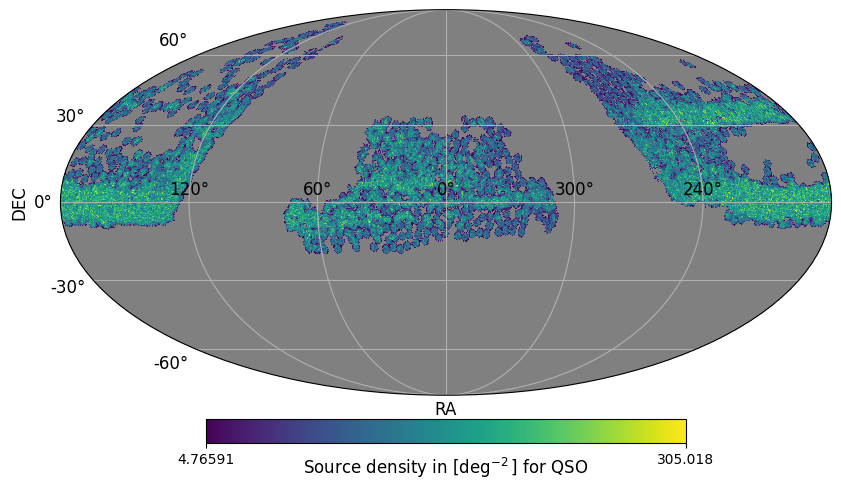

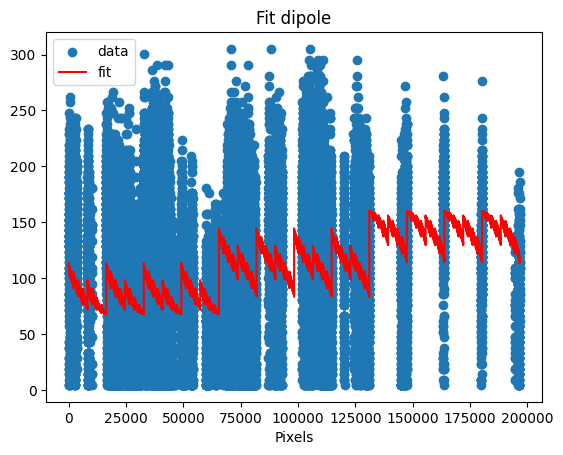

In [5]:
init =  (200, 1, 100, 40)
m = ALL_Mapper.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside)
m

### From simulation

Total number of sources in the entire sky : 12386304
Theorical number of sources in one pixel : 63


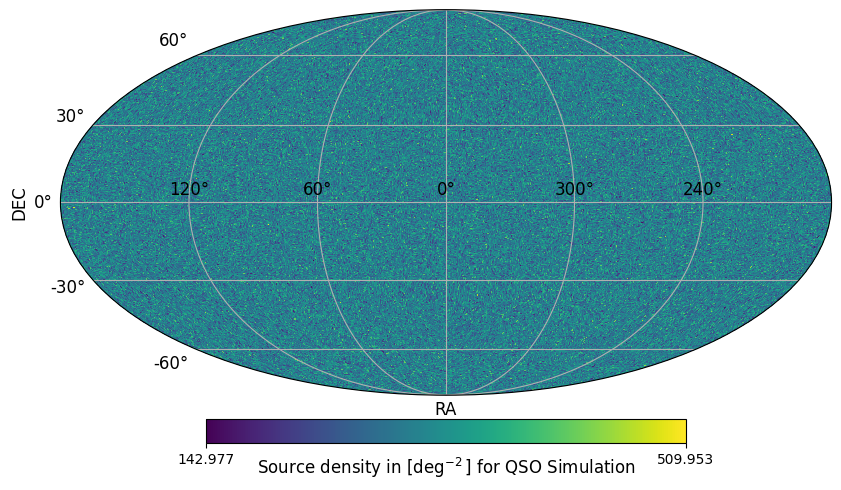

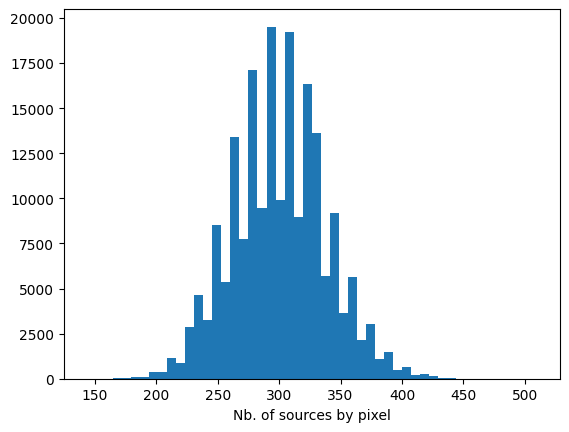

In [6]:
NSource_px_th = int(ALL_Mapper.map.max() * ALL_Mapper.area_deg2)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

#data = generate_lumMag(NSource_px_th*npix, to_table=True)
data = {}
data["RA"], data["DEC"] = generate_raDec(NSource_px_th*npix)
data = Table(data)

simu_Mapper = DensityMapper(data, nside=nside)
simu_Mapper._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper.plot('')

get_hist(simu_Mapper.map, bins=50);

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.335e+05 (χ²/ndof = 1.2)  │              Nfcn = 600              │
│ EDM = 2.38e-05 (Goal: 0.0002)    │           time = 18.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  295.50   │   0.08    │   -0.08    │    0.08    │    0    │         │       │
│ 1 │ A    │  2.5e-9   │136126.8e-9│  -2.5e-9   │136126.8e-9 │    0    │    1    │       │
│ 2 │ ra   │    100    │    200    │    -100    │    260     │    0    │   360   │       │
│ 3 │ dec  │    86     │    163    │    -163    │     4      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.08   │   0.08    │  -2.5e-9  │136126.8e-9│   -100    │    260    │   -163    │     4     │
│  Valid   │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   False   │   False   │   True    │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────┐
│     │            N*             A            ra           dec │
├─────┼─────────────────────────────────────────────────────────┤
│  N* │       0.00614    -635.6e-12         0.002         0.001 │
│   A │    -635.6e-12      1.35e-12 -3.2918081e-6 -2.0378690e-6 │
│  ra │         0.002 -3.2918081e-6      1.04e+05             0 │
│ dec │         0.001 -2.0378690e-6             0      2.73e+03 │
└─────┴─────────────────────────────────────────────────────────┘

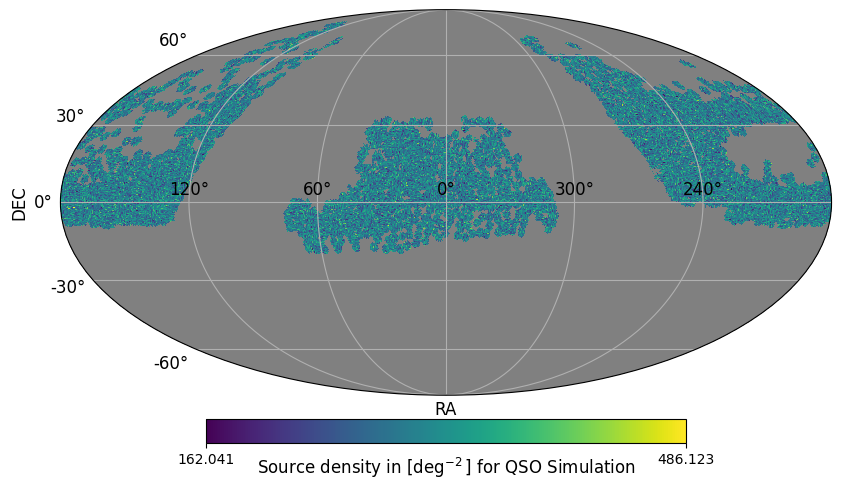

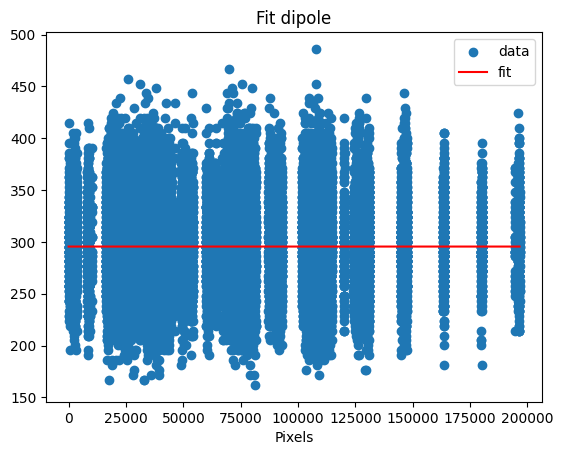

In [7]:
simu_Mapper.set_mask(mask=ALL_Mapper.mapMasked.mask)

init =  (200, 0, 100, 40)
m = simu_Mapper.fit_dipole("Masked", init)
m

### FRACCOV rescaling

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.17e+06 (χ²/ndof = 21.2)  │              Nfcn = 638              │
│ EDM = 1.25e-05 (Goal: 0.0002)    │           time = 19.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   48.55   │   0.04    │   -0.04    │    0.04    │    0    │         │       │
│ 1 │ A    │  0.8426   │  0.0014   │  -0.0014   │   0.0014   │    0    │    1    │       │
│ 2 │ ra   │  194.77   │   0.21    │   -0.21    │    0.21    │    0    │   360   │       │
│ 3 │ dec  │  -69.25   │   0.05    │   -0.05    │    0.05    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.04   │   0.04    │  -0.0014  │  0.0014   │   -0.21   │   0.21    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │  0.00158  27.5e-6  -0.0004  -0.0005 │
│   A │  27.5e-6 2.03e-06   7.6e-6 -11.5e-6 │
│  ra │  -0.0004   7.6e-6   0.0454   0.0026 │
│ dec │  -0.0005 -11.5e-6   0.0026  0.00277 │
└─────┴─────────────────────────────────────┘

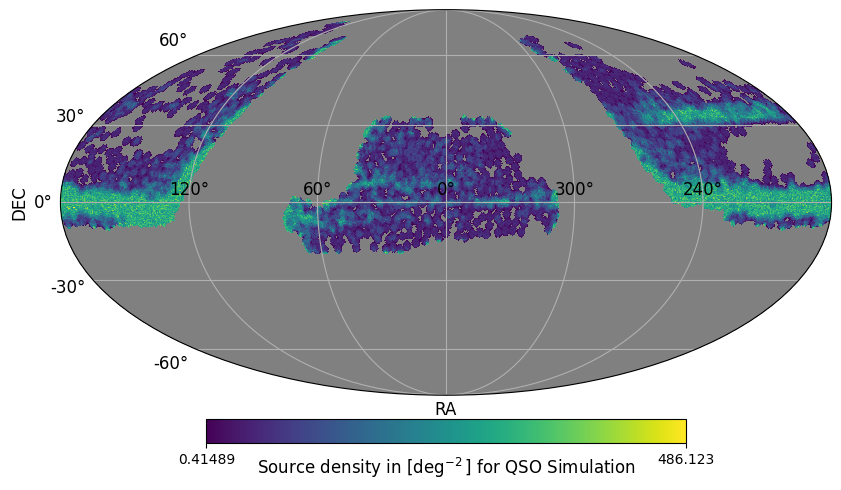

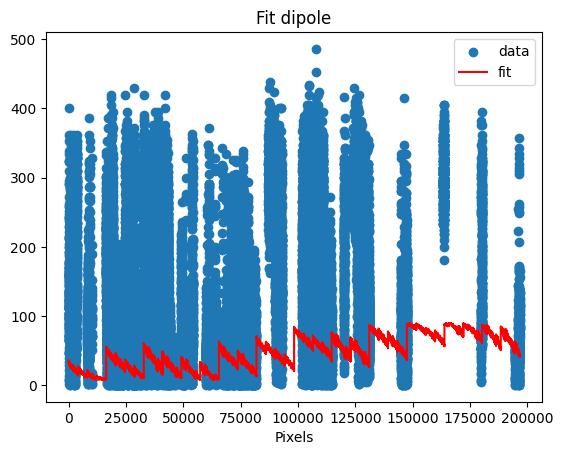

In [9]:
hpmap = simu_Mapper.map * DR1_Mapper.FRACCOVnside.filled(0)
hpmap[np.isnan(hpmap)] = 0
simu_Mapper_scale = DensityMapper.from_map(hpmap)
simu_Mapper_scale._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper_scale.set_mask()
# simu_Mapper_scale.plot("Masked")
# get_savefig(plt, output_path_Simu, suffix_Simu+"mask0");

init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.161e+06 (χ²/ndof = 5.9)  │              Nfcn = 387              │
│ EDM = 1.32e-06 (Goal: 0.0002)    │           time = 11.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  146.69   │   0.10    │   -0.10    │    0.10    │    0    │         │       │
│ 1 │ A    │  0.8804   │  0.0014   │  -0.0014   │   0.0014   │    0    │    1    │       │
│ 2 │ ra   │  185.10   │   0.15    │   -0.15    │    0.15    │    0    │   360   │       │
│ 3 │ dec  │  -66.01   │   0.06    │   -0.06    │    0.06    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.1    │    0.1    │  -0.0014  │  0.0014   │   -0.15   │   0.15    │   -0.06   │   0.06    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │  0.00991  46.7e-6    0.001  -0.0025 │
│   A │  46.7e-6 2.01e-06    28e-6 -33.6e-6 │
│  ra │    0.001    28e-6   0.0231  -0.0011 │
│ dec │  -0.0025 -33.6e-6  -0.0011   0.0031 │
└─────┴─────────────────────────────────────┘

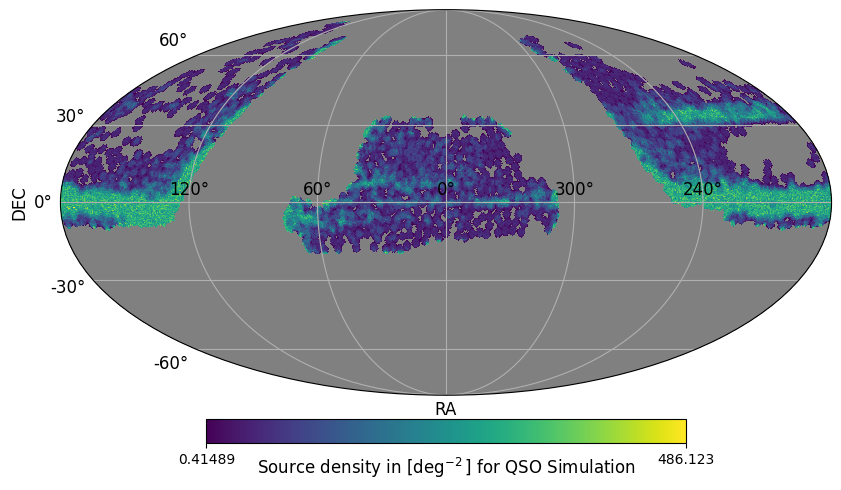

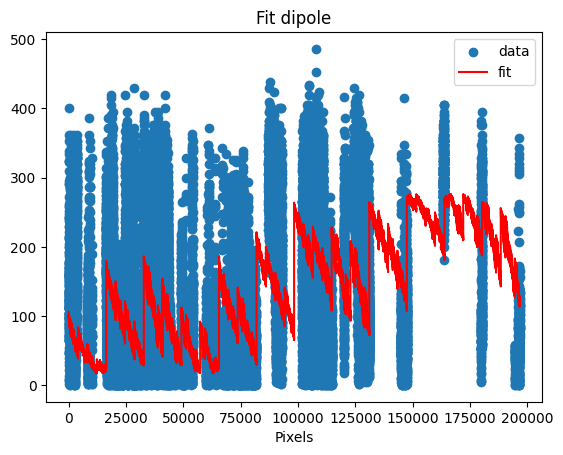

In [10]:
init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside)
m

### From Poisson noise

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.18e+06 (χ²/ndof = 21.3)  │              Nfcn = 497              │
│ EDM = 1.17e-05 (Goal: 0.0002)    │           time = 15.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   48.20   │   0.04    │   -0.04    │    0.04    │    0    │         │       │
│ 1 │ A    │  0.8343   │  0.0014   │  -0.0014   │   0.0014   │    0    │    1    │       │
│ 2 │ ra   │  194.41   │   0.21    │   -0.21    │    0.21    │    0    │   360   │       │
│ 3 │ dec  │  -68.83   │   0.05    │   -0.05    │    0.05    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.04   │   0.04    │  -0.0014  │  0.0014   │   -0.21   │   0.21    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │  0.00157  27.6e-6  -0.0004  -0.0005 │
│   A │  27.6e-6 2.05e-06   8.7e-6 -13.1e-6 │
│  ra │  -0.0004   8.7e-6   0.0454   0.0026 │
│ dec │  -0.0005 -13.1e-6   0.0026  0.00287 │
└─────┴─────────────────────────────────────┘

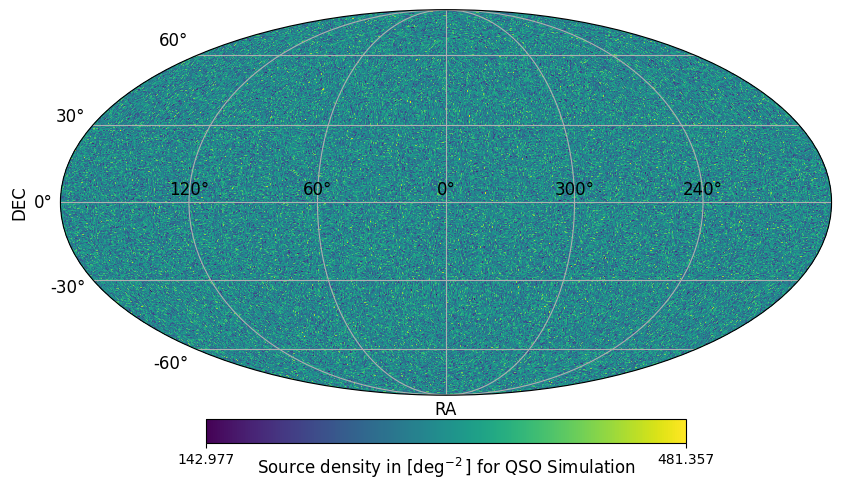

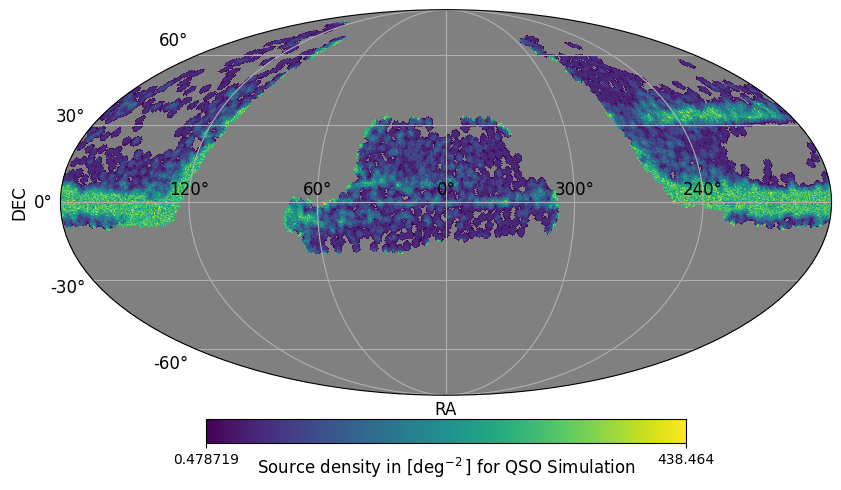

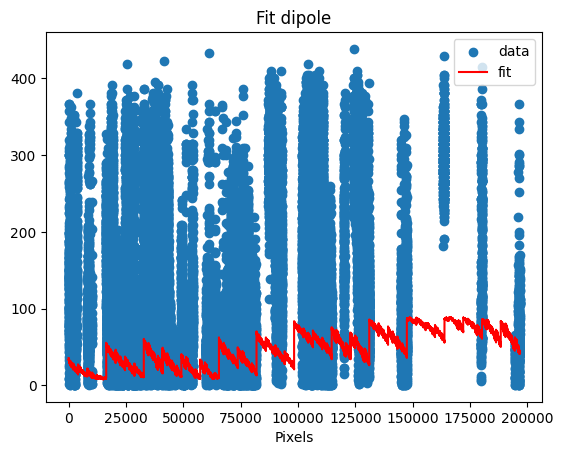

In [13]:
hpmap = np.random.poisson(NSource_px_th, npix)/area_deg2
simu_Mapper_pois = DensityMapper.from_map(hpmap)
simu_Mapper_pois._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper_pois.plot('')

hpmap = simu_Mapper_pois.map * DR1_Mapper.FRACCOVnside.filled(0)
hpmap[np.isnan(hpmap)] = 0
simu_Mapper_pois = DensityMapper.from_map(hpmap)
simu_Mapper_pois._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper_pois.set_mask()

init =  (200, 0, 100, 40)
m = simu_Mapper_pois.fit_dipole("Masked", init)
m

## FRACCOV cut

### From QSO

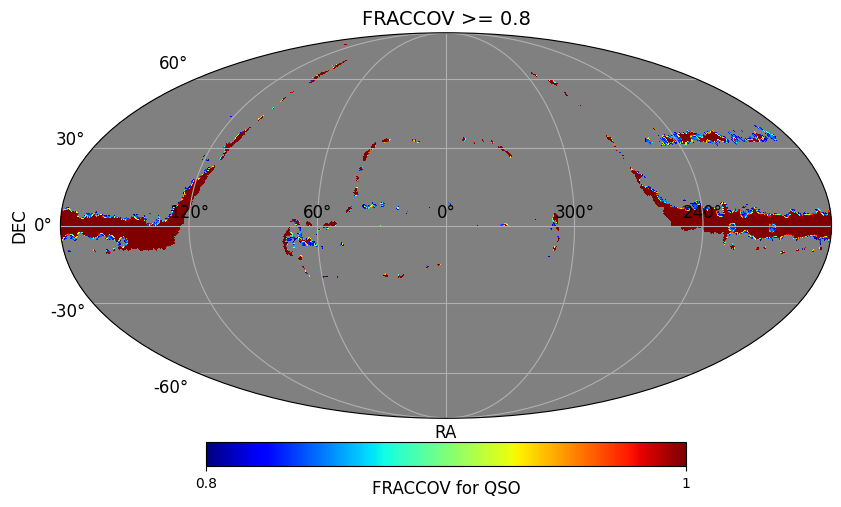

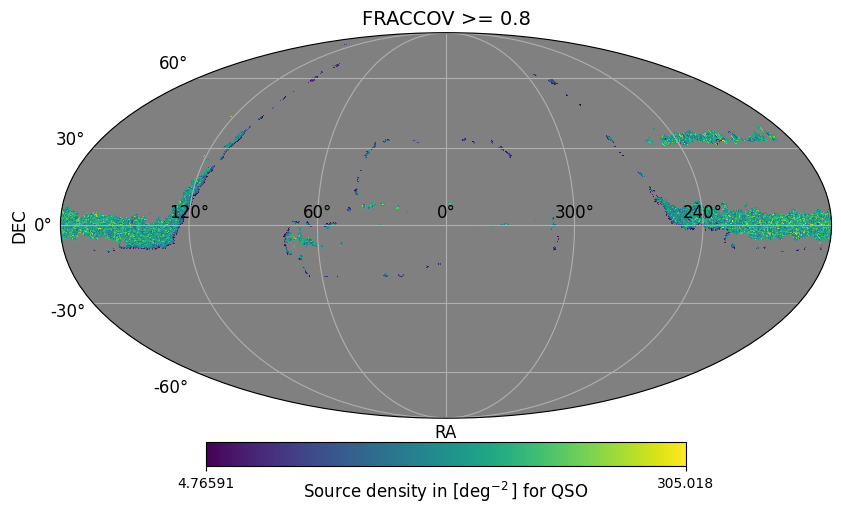

In [12]:
frac_min = 0.8
title = f'FRACCOV >= {frac_min}'

DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title=title)

ALL_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask)
ALL_Mapper.plot(use_map='Cut', title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.933e+05 (χ²/ndof = 2.0)  │              Nfcn = 877              │
│ EDM = 0.000498 (Goal: 0.0002)    │           time = 28.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  121.10   │   0.05    │   -0.05    │    0.05    │    0    │         │       │
│ 1 │ A    │  0.4507   │  0.0015   │  -0.0015   │   0.0015   │    0    │    1    │       │
│ 2 │ ra   │   0.004   │  180.354  │   -0.004   │  180.354   │    0    │   360   │       │
│ 3 │ dec  │-89.9999999977│0.0324589096│-0.0000000023│0.0324589096│   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.05    │  -0.0015  │  0.0015   │  -0.004   │  180.354  │  -2.3e-9  │32458909.6e-9│
│  Valid   │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   True    │   False   │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────┐
│     │              N*               A              ra             dec │
├─────┼─────────────────────────────────────────────────────────────────┤
│  N* │         0.00293          4.8e-6          0.0676         0.20e-9 │
│   A │          4.8e-6        2.19e-06      -8.6781e-3        -0.03e-9 │
│  ra │          0.0676      -8.6781e-3        3.41e+07 100.85124782e-3 │
│ dec │         0.20e-9        -0.03e-9 100.85124782e-3        2.99e-10 │
└─────┴─────────────────────────────────────────────────────────────────┘

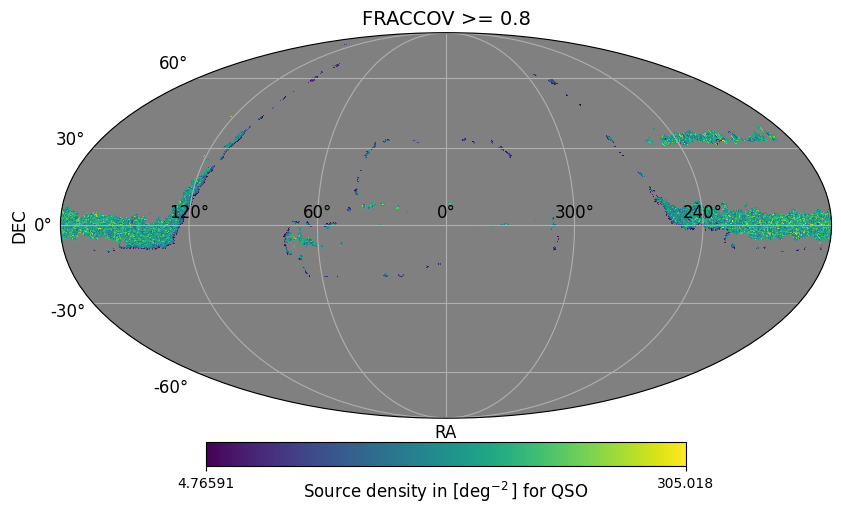

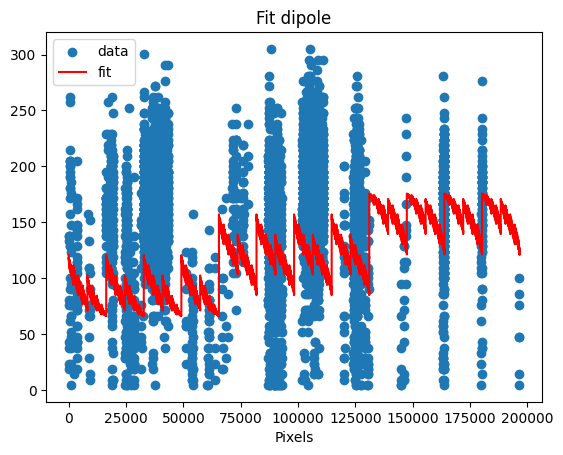

In [14]:
init =  (200, 0, 100, 40)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title)
m

### From simulation

Attribut FRACCOVcut already existed and has been replaced.


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.553e+04 (χ²/ndof = 0.3)  │              Nfcn = 574              │
│ EDM = 5.38e-09 (Goal: 0.0002)    │           time = 18.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  284.27   │   0.18    │   -0.18    │    0.18    │    0    │         │       │
│ 1 │ A    │  0.5e-12  │93830266.9e-12│  -0.5e-12  │93830266.9e-12│    0    │    1    │       │
│ 2 │ ra   │  0.18e3   │  0.26e3   │  -0.18e3   │   0.18e3   │    0    │   360   │       │
│ 3 │ dec  │    73     │    166    │    -166    │     17     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.18   │   0.18    │ -0.5e-12  │93830266.9e-12│  -0.18e3  │  0.18e3   │   -166    │    17     │
│  Valid   │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   False   │   False   │   True    │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────┐
│     │              N*               A              ra             dec │
├─────┼─────────────────────────────────────────────────────────────────┤
│  N* │           0.031    -2.11352e-12          -0.000           0.001 │
│   A │    -2.11352e-12        1.76e-16  24.11683822e-9 -49.93998855e-9 │
│  ra │          -0.000  24.11683822e-9         1.3e+05              -0 │
│ dec │           0.001 -49.93998855e-9              -0        1.08e+04 │
└─────┴─────────────────────────────────────────────────────────────────┘

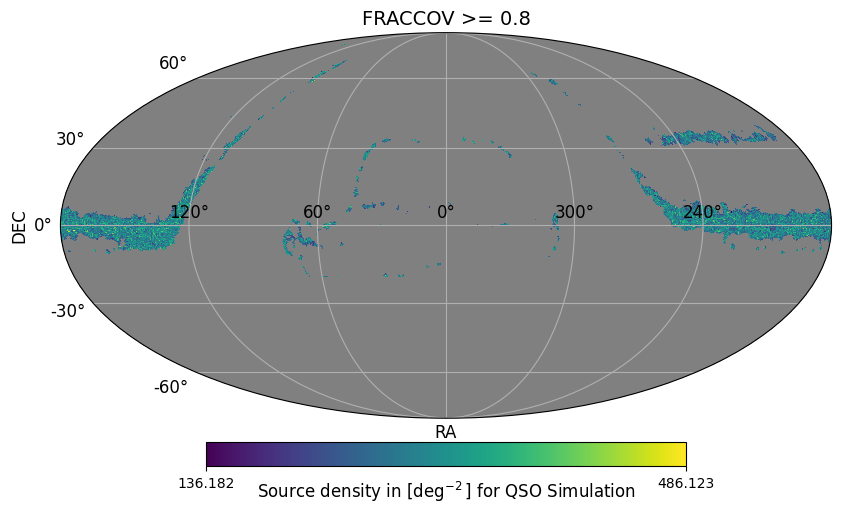

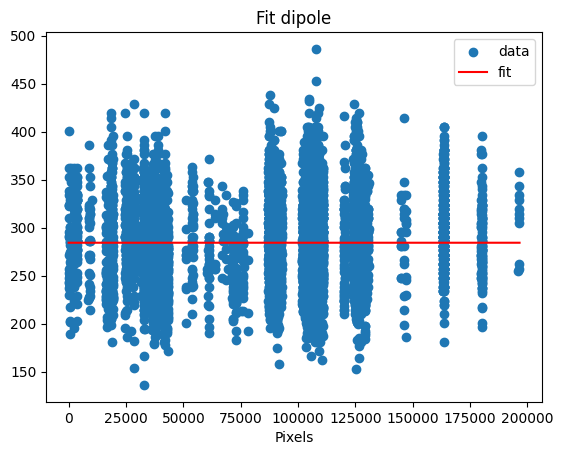

In [15]:
frac_min = 0.8
title = f'FRACCOV >= {frac_min}'
DR1_Mapper.cut_FracCov(frac_min=frac_min)
simu_Mapper_scale.set_cutMask(DR1_Mapper.FRACCOVcut.mask)

init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title)
m

## Density count > min and FRACCOV > 0.9

### From QSO

Attribut FRACCOVcut already existed and has been replaced.
Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.
Attribut mapCut already existed and has been replaced.


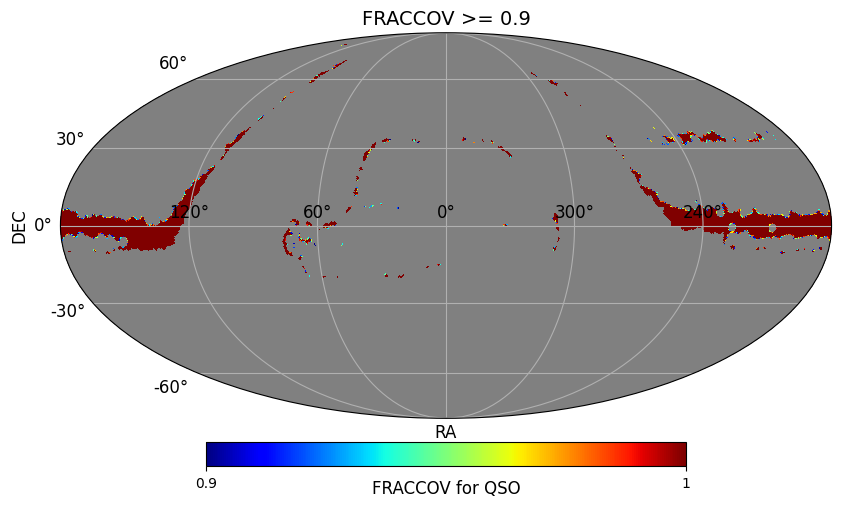

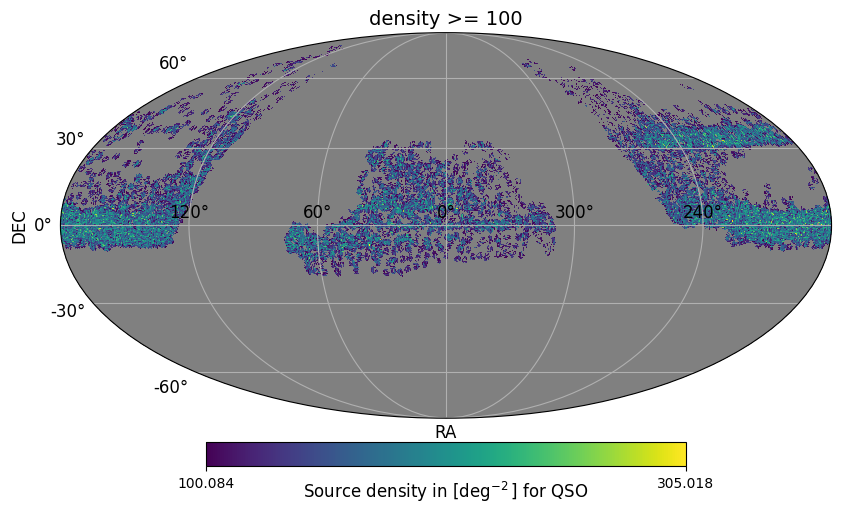

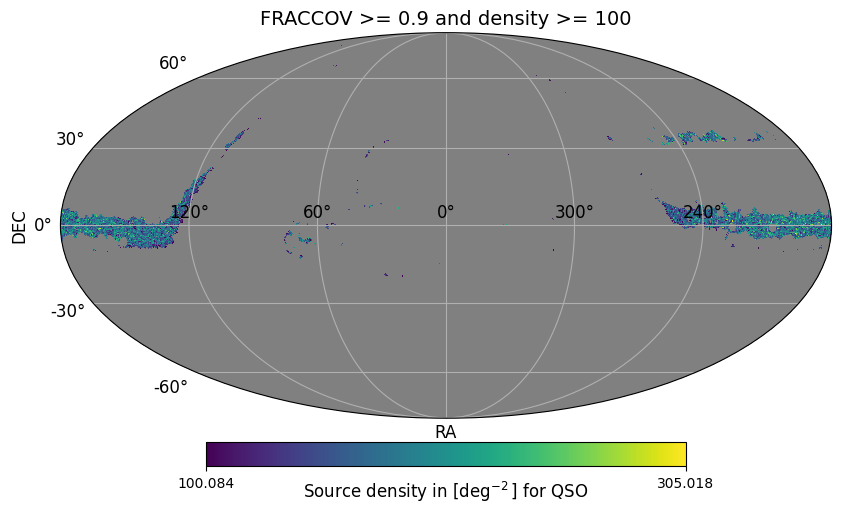

In [16]:
frac_min = 0.9
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

count_min = 100
ALL_Mapper.select_bounds(map_min=count_min)
ALL_Mapper.plot(use_map="Cut", title = f"density >= {count_min}")

title = f'FRACCOV >= {frac_min} and density >= {count_min}'
ALL_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
ALL_Mapper.plot(use_map="Cut", title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.263e+04 (χ²/ndof = 0.2)  │              Nfcn = 865              │
│ EDM = 3.52e-05 (Goal: 0.0002)    │           time = 28.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  166.44   │   0.16    │   -0.16    │    0.16    │    0    │         │       │
│ 1 │ A    │  1.6e-9   │54139.6e-9 │  -1.6e-9   │ 54139.6e-9 │    0    │    1    │       │
│ 2 │ ra   │  0.01e3   │  0.33e3   │  -0.33e3   │   0.33e3   │    0    │   360   │       │
│ 3 │ dec  │    -50    │    90     │    -90     │     90     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.16   │   0.16    │  -1.6e-9  │54139.6e-9 │  -0.33e3  │  0.33e3   │    -90    │    90     │
│  Valid   │   False   │   False   │   True    │   False   │   False   │   False   │   False   │   False   │
│ At Limit │   False   │   False   │   True    │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   True    │   True    │   True    │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────┐
│     │             N*              A             ra            dec │
├─────┼─────────────────────────────────────────────────────────────┤
│  N* │         0.0265      78.42e-12         -0.000         -0.001 │
│   A │      78.42e-12       3.45e-13  -157.24934e-9 -4.37005674e-6 │
│  ra │         -0.000  -157.24934e-9       1.15e+04              0 │
│ dec │         -0.001 -4.37005674e-6              0       2.26e+04 │
└─────┴─────────────────────────────────────────────────────────────┘

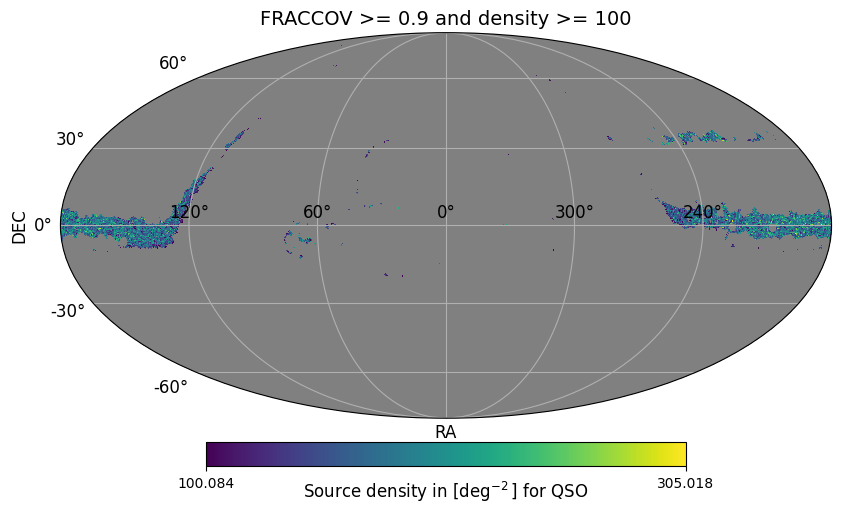

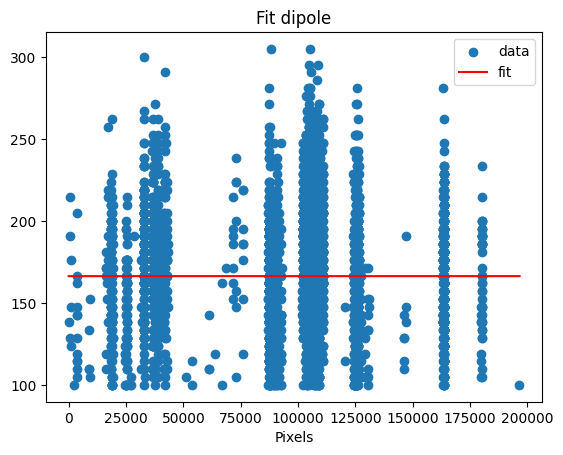

In [17]:
init =  (200, 0, 100, 40)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title)
m

### From simulation

Attribut FRACCOVcut already existed and has been replaced.
Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.
Attribut mapCut already existed and has been replaced.


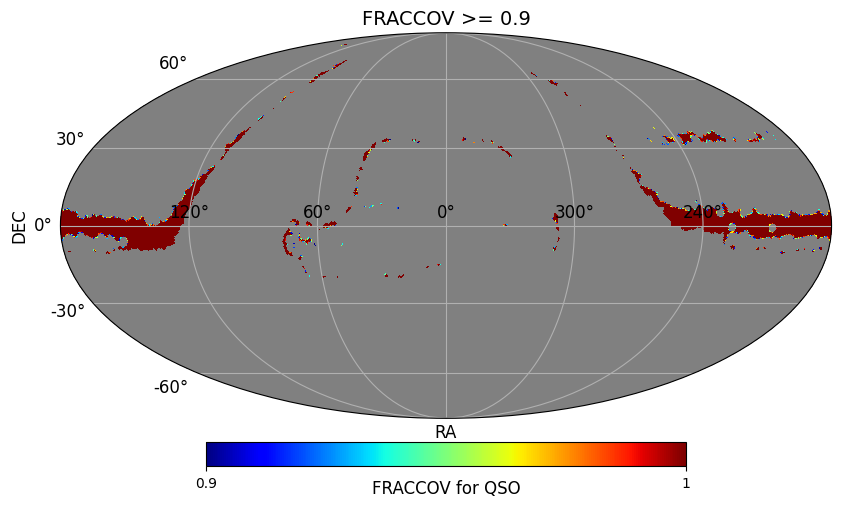

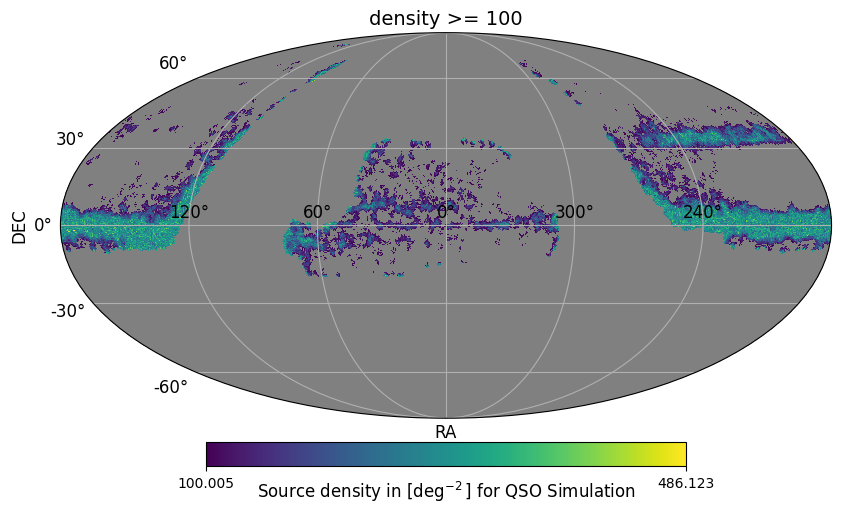

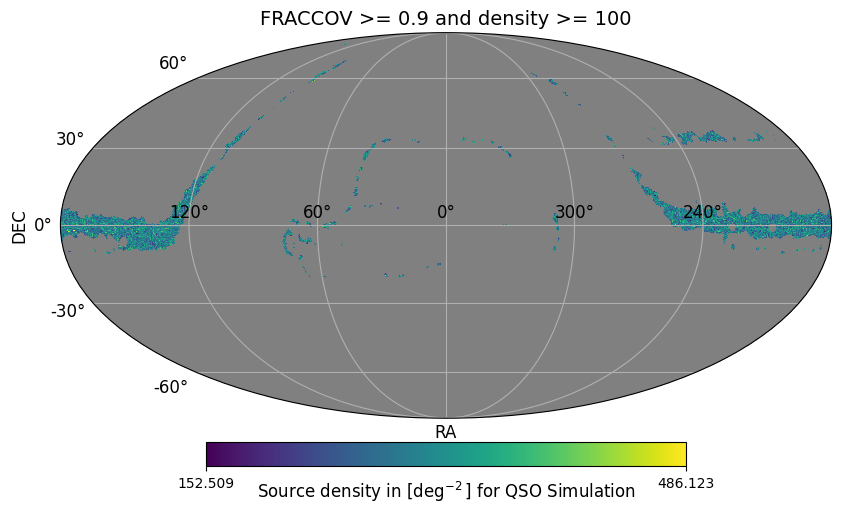

In [18]:
frac_min = 0.9
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

count_min = 100
simu_Mapper_scale.select_bounds(map_min=count_min)
simu_Mapper_scale.plot(use_map="Cut", title = f"density >= {count_min}")

title = f'FRACCOV >= {frac_min} and density >= {count_min}'
simu_Mapper_scale.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
simu_Mapper_scale.plot(use_map="Cut", title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.857e+04 (χ²/ndof = 0.2)  │              Nfcn = 703              │
│ EDM = 1.91e-06 (Goal: 0.0002)    │           time = 23.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  293.16   │   0.20    │   -0.20    │    0.20    │    0    │         │       │
│ 1 │ A    │  0.4e-9   │266246.6e-9│  -0.4e-9   │307789.2e-9 │    0    │    1    │       │
│ 2 │ ra   │    325    │    235    │    -235    │     34     │    0    │   360   │       │
│ 3 │ dec  │   86.8    │   140.7   │   -140.7   │    3.2     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.2    │    0.2    │  -0.4e-9  │307789.2e-9│   -235    │    34     │  -140.7   │    3.2    │
│  Valid   │   False   │   False   │   True    │   True    │   False   │   True    │   False   │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   False   │   True    │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   False   │   True    │   False   │   True    │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │      0.0386   -52.3e-12       -0.00       -0.00 │
│   A │   -52.3e-12    4.03e-13 336.4418e-9 906.7981e-9 │
│  ra │       -0.00 336.4418e-9    4.49e+04           0 │
│ dec │       -0.00 906.7981e-9           0    2.26e+03 │
└─────┴─────────────────────────────────────────────────┘

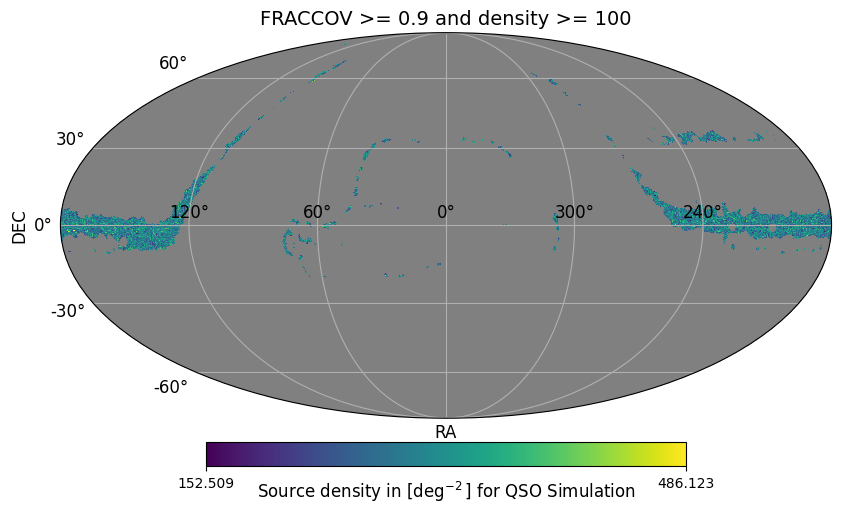

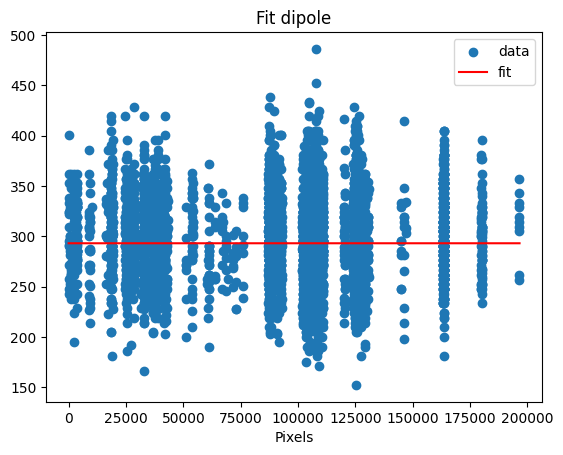

In [19]:
init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title)
m

## Correcting data

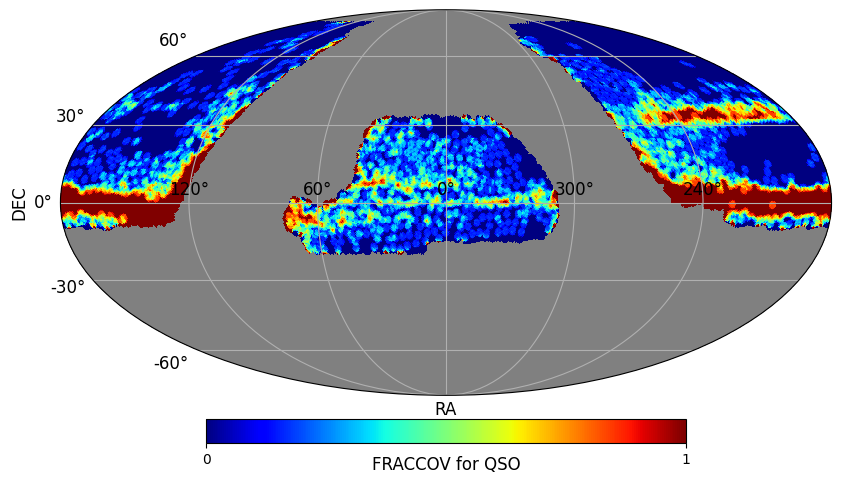

In [20]:
DR1_Mapper.plot("nside")

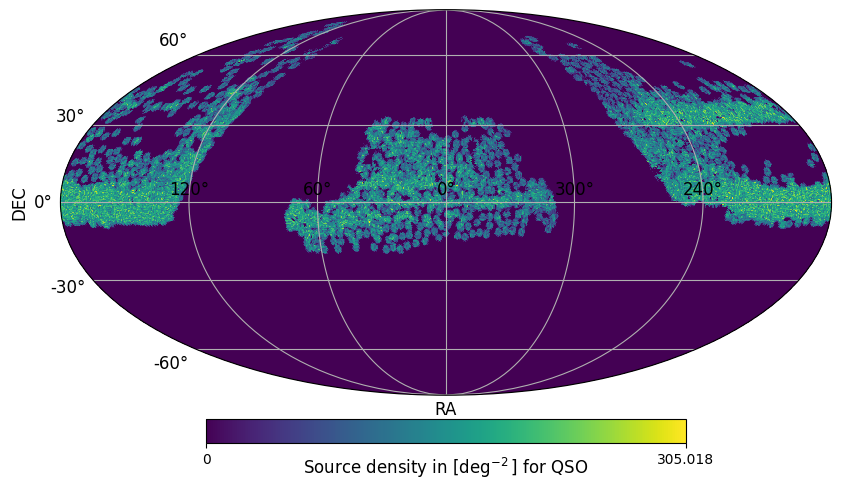

In [21]:
ALL_Mapper.plot("")

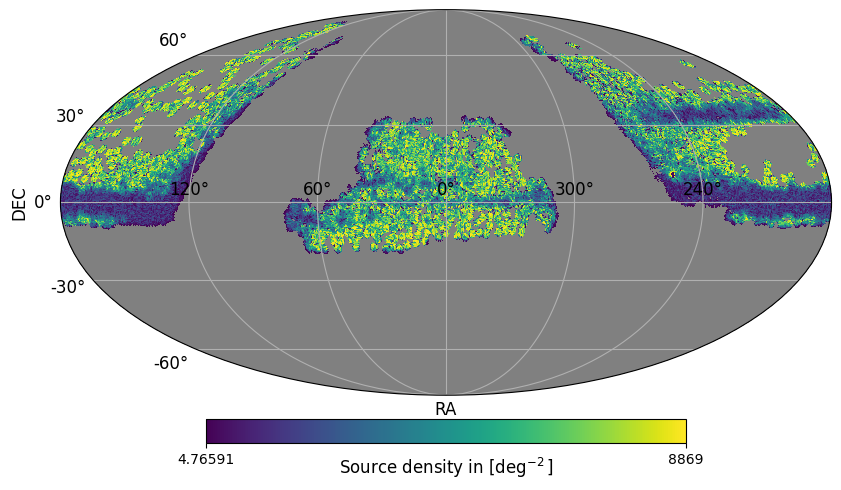

In [22]:
ALLCorrectMapper = DensityMapper.from_map((ALL_Mapper.map / DR1_Mapper.FRACCOVnside).data.data)
ALLCorrectMapper.set_mask()
ALLCorrectMapper.plot("Masked", norm="hist")

In [23]:
mask = DR1_Mapper.FRACCOVnside.data.data == 1
DR1_Mapper.FRACCOVnside.data[mask]

masked_array(data=[1.0, 1.0, 1.0, ..., 1.0, 1.0, 1.0],
             mask=[False, False, False, ..., False, False, False],
       fill_value=1e+20)

In [24]:
mask2 = ALL_Mapper.map > 305
ALL_Mapper.map[mask]

array([ 0.        ,  0.        ,  0.        , ..., 47.65912411,
       47.65912411,  0.        ])

In [25]:
test = ALL_Mapper.map /DR1_Mapper.FRACCOVnside
test

347.23422151921244
291.8836308993949
268.75746629736597
267.51033188299306
257.04912403820737
261.81981038801064
268.3285694830075
428.42468976832356
298.4666865366247
370.4319776435984
245.69951208619952


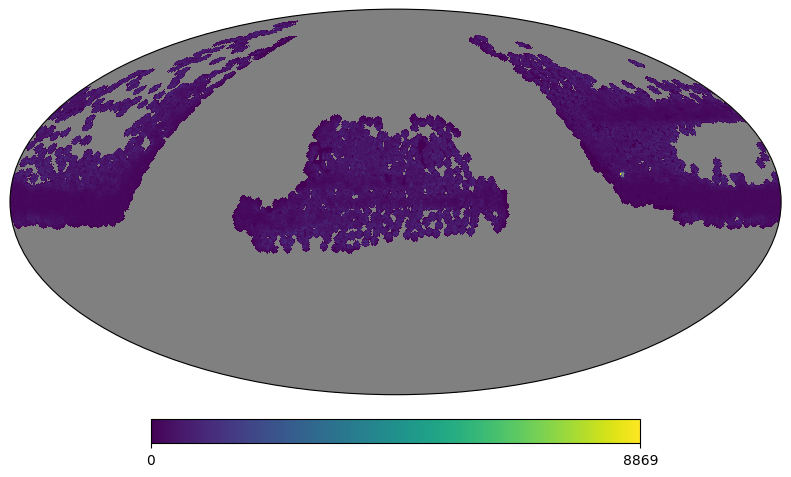

In [26]:
hp.projview((ALL_Mapper.map / DR1_Mapper.FRACCOVnside), nest=True);

## Introducing clustering

In [27]:
DIRcl = "Simulation/Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
FILEcl = DIRcl + sufix + '.fits'

data = fitsio.FITS(FILEcl)
data


  file: Simulation/Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY
  3      BINARY_TBL      FIT_MINUIT

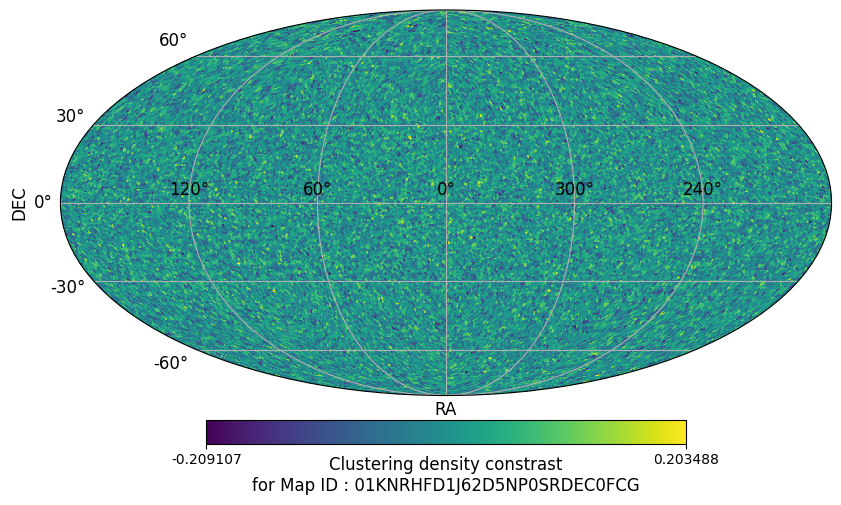

In [28]:
from Simulation.mappers import CountMapper

mapID, hpmap = data['MAPS'][0] #first clustering map
clMapper = CountMapper.from_map(hpmap)
clMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nfor Map ID : {mapID}")
clMapper.plot()

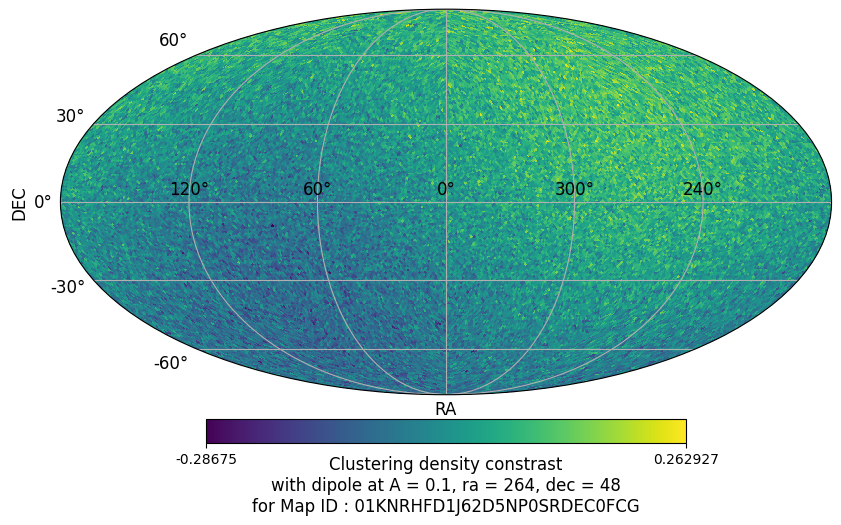

In [29]:
A, ra, dec = 0.1, 264, 48
clDipole = apply_dipole_MD(clMapper.map, clMapper.map, A, ra, dec, nest=True)
clDipoleMapper = CountMapper.from_map(clDipole)
clDipoleMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nwith dipole at A = {A}, ra = {ra}, dec = {dec}\nfor Map ID : {mapID}")
clDipoleMapper.plot()

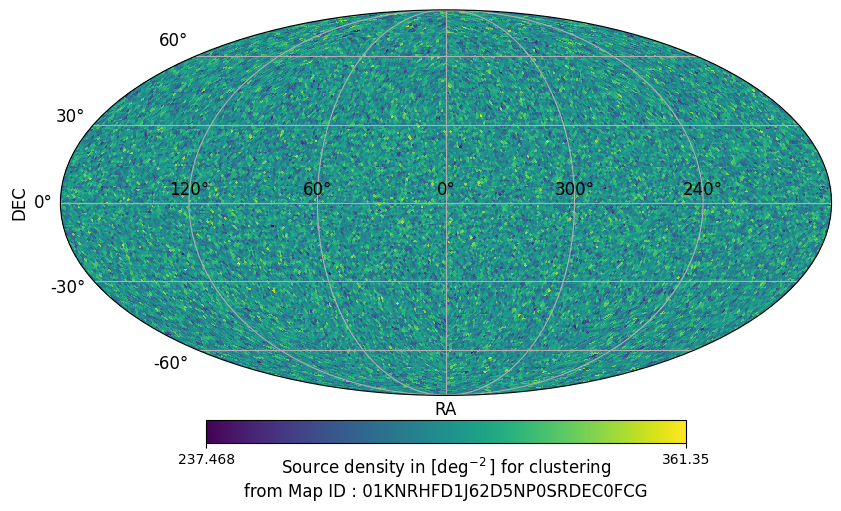

In [30]:
clMonop = apply_monopole_Mcontrast(clMapper.map, NSource_px_th/area_deg2)
clMonopMapper = DensityMapper.from_map(clMonop)
clMonopMapper._set_suffixTextPlot(unit = f"clustering\nfrom Map ID : {mapID}")
clMonopMapper.plot()

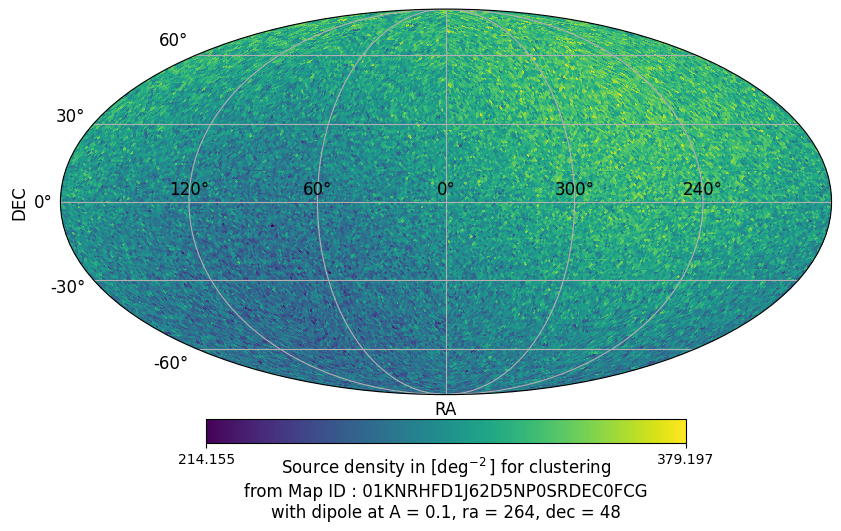

In [31]:
clDipMonop = apply_monopole_Mcontrast(clDipoleMapper.map, NSource_px_th/area_deg2)
clDipMonopMapper = DensityMapper.from_map(clDipMonop)
clDipMonopMapper._set_suffixTextPlot(unit = f"clustering\nfrom Map ID : {mapID}\nwith dipole at A = {A}, ra = {ra}, dec = {dec}")
clDipMonopMapper.plot()